# Tester_branch에서 성능 확인 진행

In [1]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

''' 데이터 코드를 작성해주세요 '''

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 0.9224137931034484


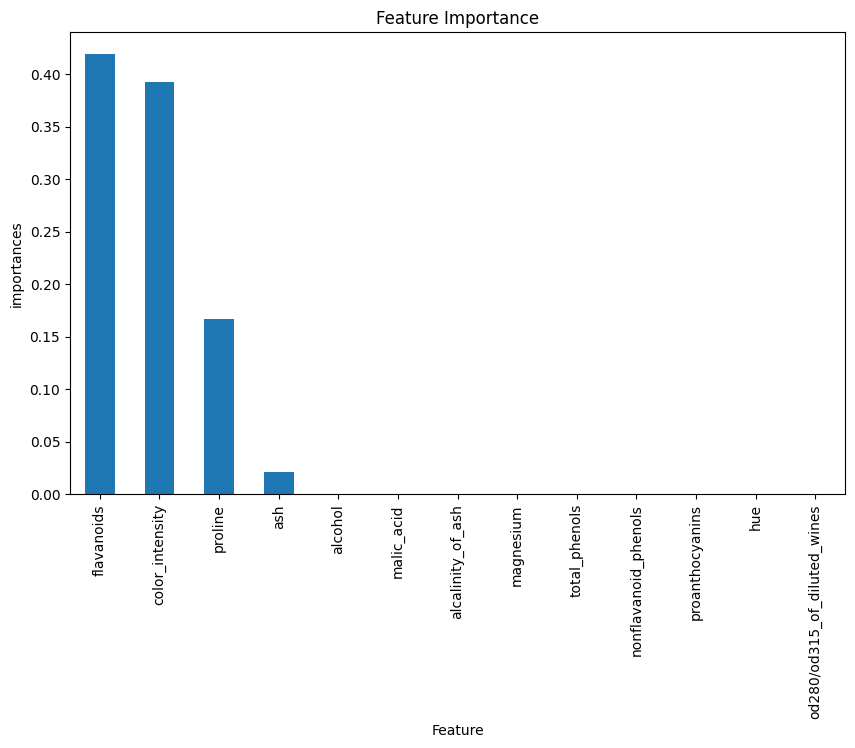

In [2]:
####### A 작업자 작업 수행 #######

import numpy as np
from sklearn.tree import DecisionTreeClassifier


param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(estimator=dt,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)


best_dt = grid_search.best_estimator_

# Feature Importance 시각화
feat_importances = pd.Series(best_dt.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='bar')
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("importances")
plt.show()

Fitting 5 folds for each of 60 candidates, totalling 300 fits


/opt/homebrew/anaconda3/envs/practice/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [15:13:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/homebrew/anaconda3/envs/practice/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [15:13:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/homebrew/anaconda3/envs/practice/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [15:13:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/homebrew/anaconda3/envs/practice/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [15:13:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } ar

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV Accuracy: 0.9576354679802955


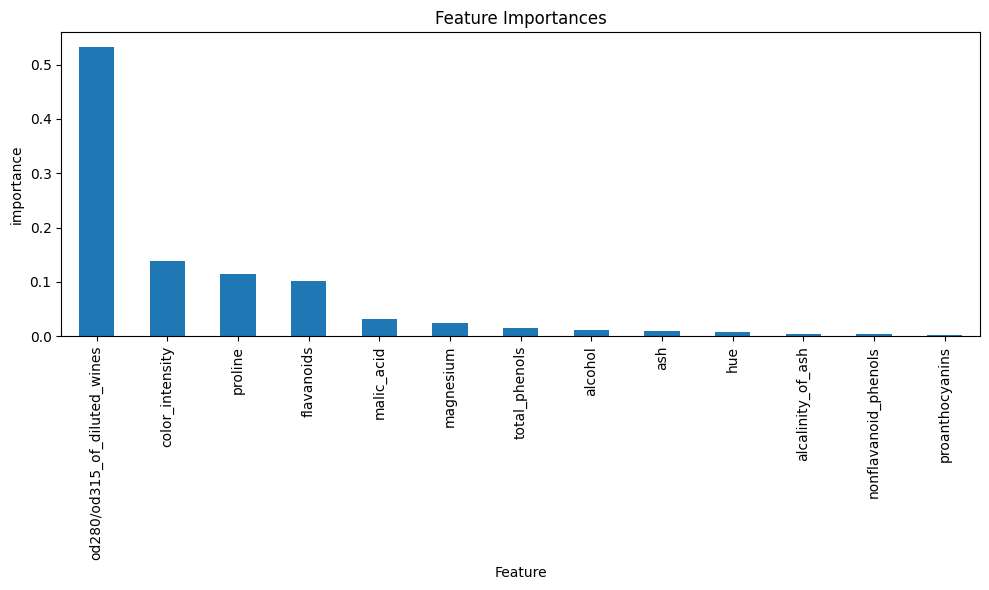

In [ ]:
####### B 작업자 작업 수행 #######

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd

param_grid = {
    'max_depth': [3, 5, 7, 9, 15],
    'learning_rate': [0.1, 0.01, 0.001],
    'n_estimators': [50, 100, 200, 300]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

grid_search_xgb = GridSearchCV(estimator=xgb,
                                param_grid=param_grid,
                                cv=5,
                                scoring='accuracy',
                                verbose=1,
                                n_jobs=-1)

grid_search_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_search_xgb.best_params_)
print("Best CV Accuracy:", grid_search_xgb.best_score_)

best_xgb = grid_search_xgb.best_estimator_

# Feature Importance 시각화
importances = best_xgb.feature_importances_
feat_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='bar')
plt.title("Feature Importances")
plt.xlabel("Feature")
plt.ylabel("importance")
plt.tight_layout()
plt.show()

# DT 모델링 성능

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("================== DT 성능 확인 ==================")

y_pred_dt = best_dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"DT accuracy : {dt_accuracy}")

print(classification_report(y_test, y_pred_dt))

================== DT 성능 확인 ==================
DT accuracy : 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



# XGB 모델링 성능

In [5]:
print("================== XGB 성능 확인 ==================")

y_pred_xgb = best_xgb.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGB accuracy : {xgb_accuracy}")

print(classification_report(y_test, y_pred_xgb))

================== XGB 성능 확인 ==================
XGB accuracy : 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



# 성능 비교 시각화

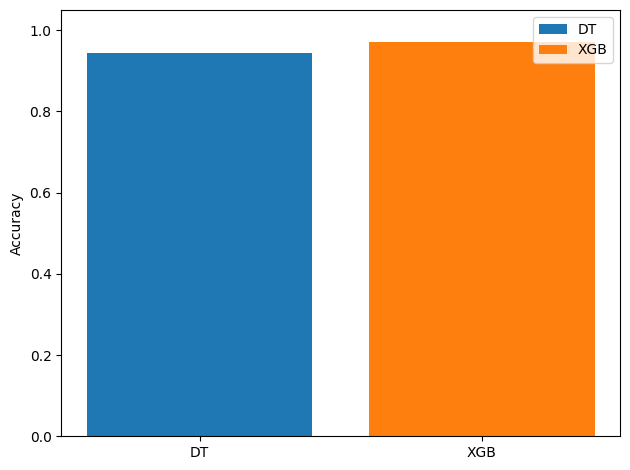

In [ ]:
import matplotlib.pyplot as plt

plt.bar(['DT'], [acc_dt], label='DT')
plt.bar(['XGB'], [acc_xgb], label='XGB')
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()